In [1]:
# ==========================================
# 1. IMPORT LIBRARIES
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, confusion_matrix, roc_curve, roc_auc_score)

from imblearn.over_sampling import SMOTE
import joblib
import warnings
warnings.filterwarnings("ignore")

In [2]:
# ==========================================
# 2. LOAD DATASET
# ==========================================

df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

print("Shape:", df.shape)
df.head(10)

Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes
6,1452-KIOVK,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.4,No
7,6713-OKOMC,Female,0,No,No,10,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.9,No
8,7892-POOKP,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
9,6388-TABGU,Male,0,No,Yes,62,Yes,No,DSL,Yes,...,No,No,No,No,One year,No,Bank transfer (automatic),56.15,3487.95,No


In [3]:
df.info()

# Check churn distribution
df["Churn"].value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [4]:
# ==========================================
# DATA CLEANING
# ==========================================

# Convert TotalCharges to numeric
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

# Remove customerID
df.drop("customerID", axis=1, inplace=True)

# Remove duplicates
df.drop_duplicates(inplace=True)

# Fill missing TotalCharges with median
df["TotalCharges"].fillna(df["TotalCharges"].median(), inplace=True)

df.isnull().sum()

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

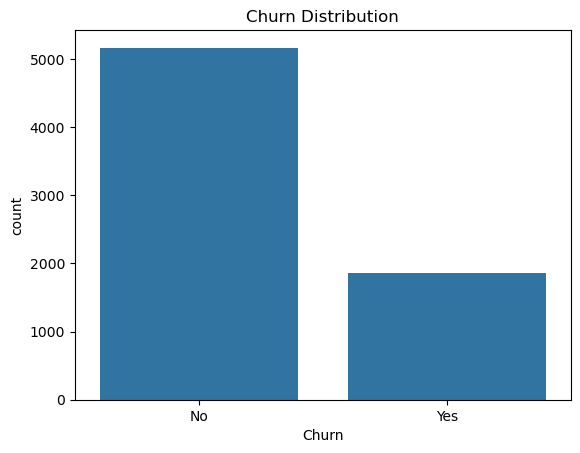

In [5]:
sns.countplot(x="Churn", data=df)
plt.title("Churn Distribution")
plt.show()

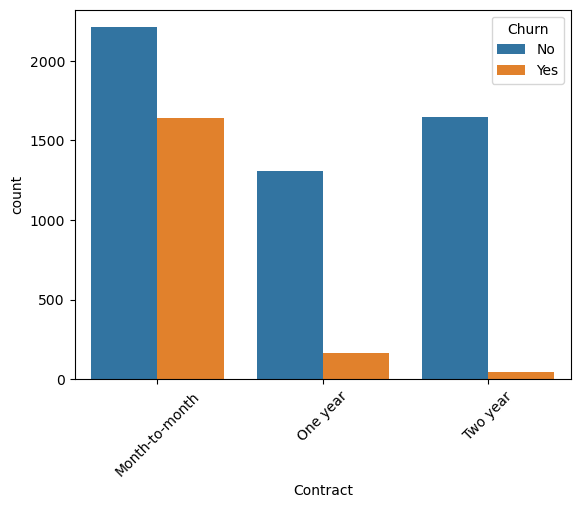

In [6]:
sns.countplot(x="Contract", hue="Churn", data=df)
plt.xticks(rotation=45)
plt.show()

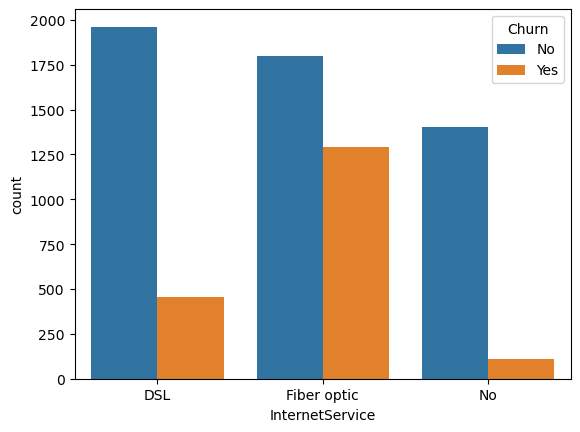

In [7]:
sns.countplot(x="InternetService", hue="Churn", data=df)
plt.show()

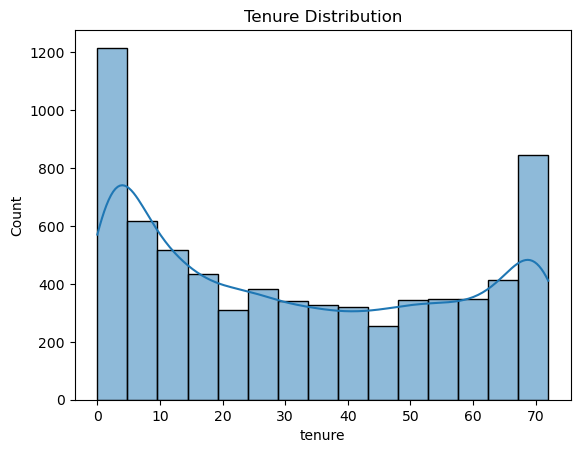

In [8]:
sns.histplot(df["tenure"], kde=True)
plt.title("Tenure Distribution")
plt.show()

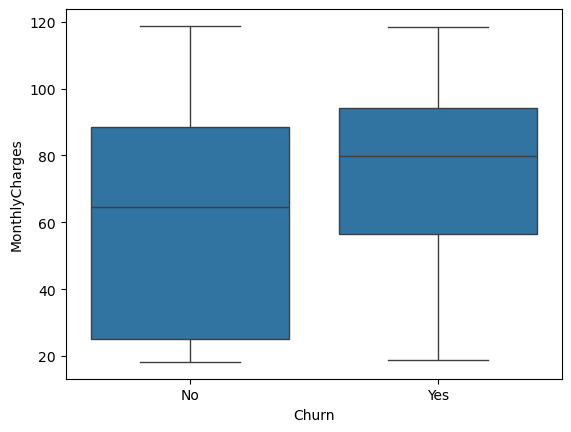

In [9]:
sns.boxplot(x="Churn", y="MonthlyCharges", data=df)
plt.show()

In [10]:
# ==========================================
# FEATURE ENGINEERING
# ==========================================

# Convert target to binary
df["Churn"] = df["Churn"].map({"Yes":1, "No":0})

# Create AvgChargePerMonth
df["AvgChargePerMonth"] = df["TotalCharges"] / (df["tenure"] + 1)

# One-hot encoding
df = pd.get_dummies(df, drop_first=True)

print("Shape after encoding:", df.shape)

Shape after encoding: (7021, 32)


In [11]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

In [12]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

print("Train class distribution:")
print(pd.Series(y_train).value_counts())

Train size: (5616, 31)
Test size: (1405, 31)
Train class distribution:
Churn
0    4131
1    1485
Name: count, dtype: int64


In [14]:
sm = SMOTE(random_state=42)
X_train_sm, y_train_sm = sm.fit_resample(X_train, y_train)

print("After SMOTE:", pd.Series(y_train_sm).value_counts())

After SMOTE: Churn
1    4131
0    4131
Name: count, dtype: int64


In [15]:
# ==========================================
# MODEL BUILDING
# ==========================================

lr = LogisticRegression()
dt = DecisionTreeClassifier()
rf = RandomForestClassifier(random_state=42)
gb = GradientBoostingClassifier(random_state=42)

models = [lr, dt, rf, gb]

for model in models:
    model.fit(X_train_sm, y_train_sm)
    print(model.__class__.__name__, 
          "Train Accuracy:", model.score(X_train_sm, y_train_sm))

LogisticRegression Train Accuracy: 0.7879448075526507
DecisionTreeClassifier Train Accuracy: 0.9984265311062697
RandomForestClassifier Train Accuracy: 0.9984265311062697
GradientBoostingClassifier Train Accuracy: 0.8569353667392883


In [16]:
for model in models:
    scores = cross_val_score(model, X_train_sm, y_train_sm, cv=5)
    print(model.__class__.__name__, "CV Mean Accuracy:", scores.mean())

LogisticRegression CV Mean Accuracy: 0.7863749086333602
DecisionTreeClassifier CV Mean Accuracy: 0.7832354117321358
RandomForestClassifier CV Mean Accuracy: 0.8489613865171404
GradientBoostingClassifier CV Mean Accuracy: 0.835528329883739


In [17]:
best_model = rf
y_pred = best_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

Accuracy: 0.7722419928825622
Precision: 0.5714285714285714
Recall: 0.5591397849462365
F1 Score: 0.5652173913043478


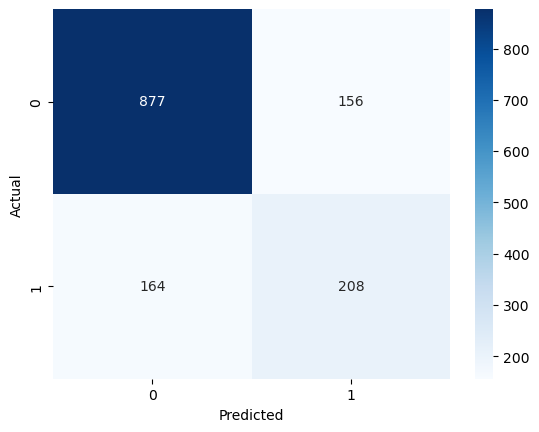

In [18]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

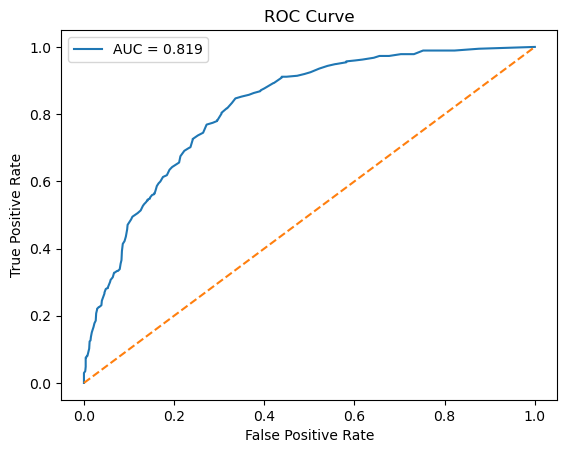

In [19]:
y_prob = best_model.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc_score = roc_auc_score(y_test, y_prob)

plt.plot(fpr, tpr, label=f"AUC = {auc_score:.3f}")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [20]:
param_grid = {
    "n_estimators": [100,200],
    "max_depth": [None,10,20],
    "min_samples_split": [2,5]
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    n_jobs=-1
)

grid.fit(X_train_sm, y_train_sm)

print("Best Parameters:", grid.best_params_)

best_model = grid.best_estimator_

Best Parameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}


In [21]:
importances = best_model.feature_importances_
feature_names = X.columns

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values("Importance", ascending=False)

importance_df.head(10)

,Feature,Importance
1,tenure,0.142693
3,TotalCharges,0.121420
4,AvgChargePerMonth,0.106912
2,MonthlyCharges,0.104861
26,Contract_Two year,0.062896
11,InternetService_Fiber optic,0.047370
29,PaymentMethod_Electronic check,0.043981
27,PaperlessBilling_Yes,0.034660
25,Contract_One year,0.031565
14,OnlineSecurity_Yes,0.030885


In [22]:
# Risk score between 0-100
risk_scores = best_model.predict_proba(X_test)[:,1] * 100

risk_df = pd.DataFrame({
    "Actual_Churn": y_test,
    "Risk_Score": risk_scores
})

risk_df.head()

,Actual_Churn,Risk_Score
5627,0,90.0
6126,1,65.0
2361,1,65.0
2201,0,15.0
832,0,28.0


In [23]:
joblib.dump(best_model, "churn_model.pkl")
joblib.dump(scaler, "scaler.pkl")

print("Model Saved Successfully!")

Model Saved Successfully!
